<a href="https://colab.research.google.com/github/intanypurbasari/hello-world/blob/master/Cats_and_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
import os
import zipfile
import shutil
import random

# Assuming the user has manually uploaded 'kagglecatsanddogs_5340.zip'
# You might need to adjust this path if your uploaded file has a different name or location.
zip_file_path = '/content/kagglecatsanddogs_5340.zip'

# Define the target directory for extracted contents
base_extract_path = '/content/cats_and_dogs_data_extracted'
os.makedirs(base_extract_path, exist_ok=True)

print(f"Attempting to extract {zip_file_path} to {base_extract_path}...")
try:
  if os.path.exists(zip_file_path) and os.path.getsize(zip_file_path) > 0:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(base_extract_path)
    print("Extraction successful.")

    # Determine the actual directory containing 'Cat' and 'Dog' folders
    source_data_root = None
    potential_dirs = [
        os.path.join(base_extract_path, 'cats_and_dogs_filtered'),
        os.path.join(base_extract_path, 'PetImages')
    ]

    for p_dir in potential_dirs:
        if os.path.exists(p_dir) and (os.path.isdir(os.path.join(p_dir, 'Cat')) or os.path.isdir(os.path.join(p_dir, 'Dog'))):
            source_data_root = p_dir
            break

    if source_data_root is None:
        # Fallback: check if Cat/Dog are directly under base_extract_path (less common for zip extraction)
        if os.path.isdir(os.path.join(base_extract_path, 'Cat')) or os.path.isdir(os.path.join(base_extract_path, 'Dog')):
            source_data_root = base_extract_path
        else:
            print(f"Error: Could not find 'Cat' or 'Dog' directories under {base_extract_path} or its known subdirectories.")
            print("Please inspect the extracted contents and adjust 'source_data_root' manually.")
            raise FileNotFoundError("Could not locate source 'Cat'/'Dog' directories after extraction.")

    print(f"Identified source data root: {source_data_root}")

    # Now, set up the actual train and validation directories
    train_base_dir = os.path.join(base_extract_path, 'train_data_split')
    validation_base_dir = os.path.join(base_extract_path, 'validation_data_split')

    os.makedirs(os.path.join(train_base_dir, 'Cat'), exist_ok=True)
    os.makedirs(os.path.join(train_base_dir, 'Dog'), exist_ok=True)
    os.makedirs(os.path.join(validation_base_dir, 'Cat'), exist_ok=True)
    os.makedirs(os.path.join(validation_base_dir, 'Dog'), exist_ok=True)

    # Function to split and copy images
    def split_data(source_dir, train_target_dir, val_target_dir, split_ratio=0.8):
        for class_name in ['Cat', 'Dog']:
            class_source_dir = os.path.join(source_dir, class_name)
            if not os.path.isdir(class_source_dir):
                print(f"Warning: Class directory '{class_source_dir}' not found. Skipping {class_name} split.")
                continue

            all_files = [f for f in os.listdir(class_source_dir) if os.path.isfile(os.path.join(class_source_dir, f))]
            # Filter out potentially corrupted files (e.g., '666.jpg' in this dataset) and zero-byte files
            all_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg')) and os.path.getsize(os.path.join(class_source_dir, f)) > 0]

            random.shuffle(all_files)
            num_train = int(len(all_files) * split_ratio)

            train_files = all_files[:num_train]
            val_files = all_files[num_train:]

            print(f"Splitting {len(all_files)} {class_name} images: {len(train_files)} for training, {len(val_files)} for validation.")

            # Copy to training directory
            for f_name in train_files:
                src_path = os.path.join(class_source_dir, f_name)
                dst_path = os.path.join(train_target_dir, class_name, f_name)
                try:
                    shutil.copyfile(src_path, dst_path)
                except Exception as e:
                    print(f"Could not copy {src_path} to {dst_path}: {e}")

            # Copy to validation directory
            for f_name in val_files:
                src_path = os.path.join(class_source_dir, f_name)
                dst_path = os.path.join(val_target_dir, class_name, f_name)
                try:
                    shutil.copyfile(src_path, dst_path)
                except Exception as e:
                    print(f"Could not copy {src_path} to {dst_path}: {e}")

    split_data(source_data_root, train_base_dir, validation_base_dir)

    train_dir = train_base_dir
    validation_dir = validation_base_dir

    print(f"Train directory: {train_dir}")
    print(f"Validation directory: {validation_dir}")
  else:
    print(f"Error: The specified zip file {zip_file_path} is empty or missing.")
    print("Please ensure the file was uploaded correctly and the path is accurate.")

except zipfile.BadZipFile:
  print(f"Error: The file {zip_file_path} is not a valid zip file or is corrupted.")
  print("Please ensure the uploaded file is a standard .zip archive.")
except FileNotFoundError as fnf_e:
    print(f"A file or directory was not found during data processing: {fnf_e}")
    print("Please check the dataset structure after extraction and confirm 'Cat'/'Dog' directories exist.")
except Exception as e:
  print(f"An unexpected error occurred during extraction or data preparation: {e}")
  print(f"Please verify the zip file {zip_file_path} is valid and not corrupted.")

Attempting to extract /content/kagglecatsanddogs_5340.zip to /content/cats_and_dogs_data_extracted...
Extraction successful.
Identified source data root: /content/cats_and_dogs_data_extracted/PetImages
Splitting 12499 Cat images: 9999 for training, 2500 for validation.
Splitting 12499 Dog images: 9999 for training, 2500 for validation.
Train directory: /content/cats_and_dogs_data_extracted/train_data_split
Validation directory: /content/cats_and_dogs_data_extracted/validation_data_split


In [ ]:
# 2. Data Preprocessing
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=(150, 150),
                                              batch_size=20, class_mode='binary')
val_gen = test_datagen.flow_from_directory(validation_dir, target_size=(150, 150),
                                            batch_size=20, class_mode='binary', shuffle=False)

Found 19998 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [ ]:
# 3. Build Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for Binary
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_gen, epochs=3, validation_data=val_gen)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.6399 - loss: 0.7199

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 521s 518ms/step - accuracy: 0.6745 - loss: 0.6156 - val_accuracy: 0.6554 - val_loss: 0.6059
Epoch 2/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 529s 529ms/step - accuracy: 0.7623 - loss: 0.4892 - val_accuracy: 0.7342 - val_loss: 0.5319
Epoch 3/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 526s 526ms/step - accuracy: 0.8304 - loss: 0.3725 - val_accuracy: 0.7322 - val_loss: 0.5546


250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 150ms/step


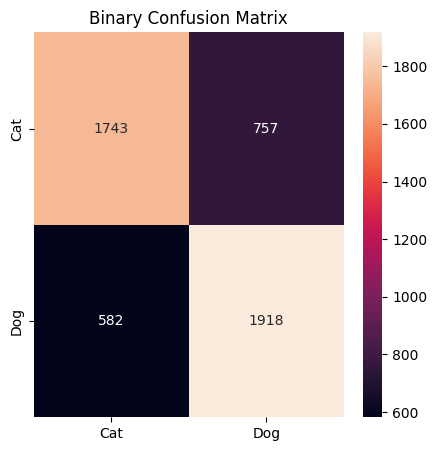

In [ ]:
# 4. Confusion Matrix
Y_pred = model.predict(val_gen)
y_pred = (Y_pred > 0.5).astype(int)
cm = confusion_matrix(val_gen.classes, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Binary Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(val_gen.classes, y_pred, target_names=['Cat', 'Dog']))

              precision    recall  f1-score   support

         Cat       0.75      0.70      0.72      2500
         Dog       0.72      0.77      0.74      2500

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.73      0.73      0.73      5000



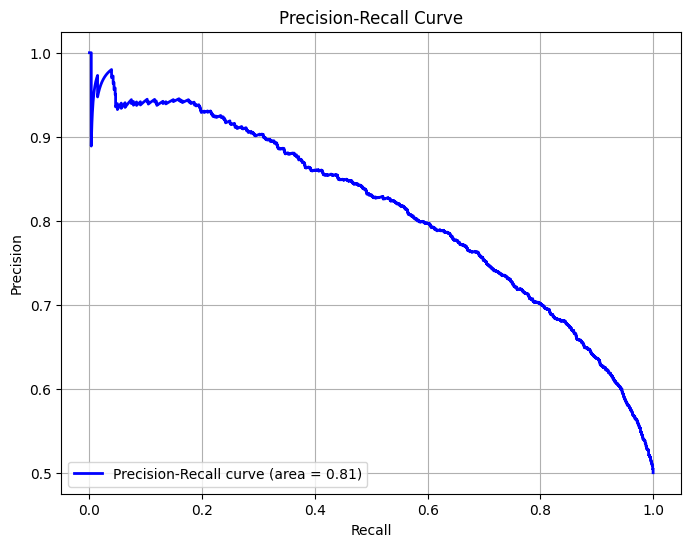

In [18]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get the true labels and predicted probabilities
y_true = val_gen.classes
y_pred_proba = Y_pred.ravel() # Flatten the predictions if they are in a column vector

# Calculate Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)

# Calculate Area Under the Precision-Recall Curve (AUPRC) or Average Precision (AP)
# Note: for binary classification task, AUPRC = AP = mean AP
auprc = auc(recall, precision)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve (area = %0.2f)' % auprc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

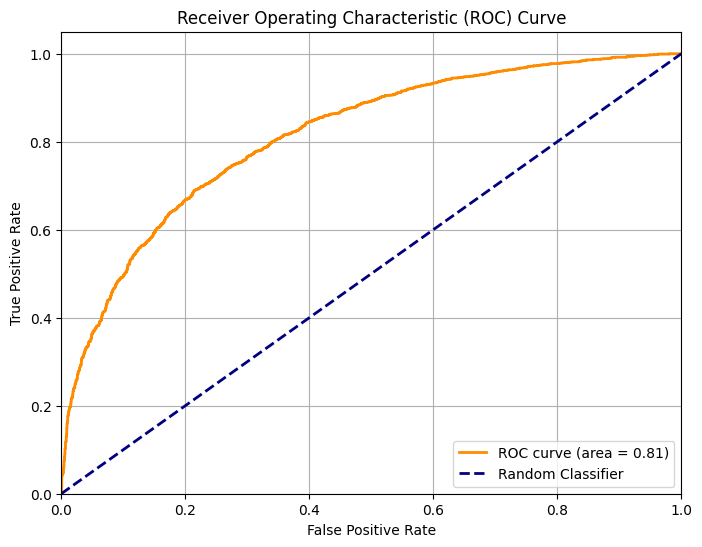

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get the true labels and predicted probabilities from the validation generator
y_true = val_gen.classes
y_pred_proba = Y_pred # Y_pred contains the predicted probabilities from the model

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()